<a href="https://colab.research.google.com/github/FarahBelghith2/PFE/blob/main/Business_Understanding_Data_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prédiction des Réservations et Optimisation Promotionnelle
## Notebook 1 – Business Understanding & Data Understanding
### Méthodologie CRISP-DM

Ce projet vise à prédire le volume de réservations par créneau horaire
et à recommander automatiquement des promotions adaptées au contexte.

Ce notebook couvre les deux premières phases de CRISP-DM :
1. Business Understanding  
2. Data Understanding  

Objectifs :
- formaliser le besoin métier,
- comprendre la structure et la qualité des données,
- explorer les premières tendances,
- préparer la transition vers la phase de Data Preparation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Business Understanding

## 1.1 Contexte métier

Le projet s’inscrit dans un contexte de gestion de réservations horaires
pour des terrains sportifs ou des infrastructures similaires.

La demande varie fortement selon :
- l’heure de la journée,
- le jour de la semaine,
- la saison,
- la météo,
- les vacances scolaires,
- les jours fériés,
- les événements locaux.

L’objectif est d’aider l’administrateur à :
- anticiper la demande future,
- identifier les créneaux creux,
- optimiser le taux d’occupation,
- proposer des promotions ciblées.

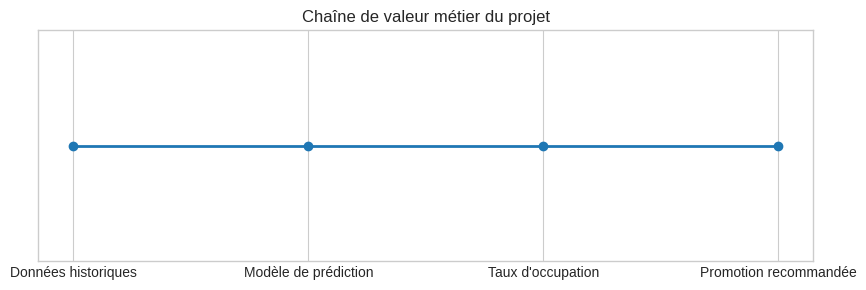

In [ ]:
labels = [
    "Données historiques",
    "Modèle de prédiction",
    "Taux d'occupation",
    "Promotion recommandée"
]

plt.figure(figsize=(10,3))
plt.plot(labels, [1,1,1,1], marker="o", linewidth=2)
plt.title("Chaîne de valeur métier du projet")
plt.yticks([])
plt.ylim(0.9, 1.1)
plt.show()


## 1.2 Problématique

**Comment prédire la demande future par créneau horaire afin d’optimiser le taux d’occupation et recommander une promotion adaptée ?**

Cette problématique comprend deux dimensions :
1. Prédire le nombre de réservations futures.
2. Aider à la décision en cas de sous‑occupation.

In [ ]:
pd.DataFrame({
    "Volet": ["Prédiction", "Décision"],
    "Question": [
        "Combien de réservations sont attendues ?",
        "Faut‑il proposer une promotion ?"
    ]
})

,Volet,Question
0,Prédiction,Combien de réservations sont attendues ?
1,Décision,Faut‑il proposer une promotion ?


## 1.3 Objectifs du projet

### Objectif principal
Développer un système de prédiction de la demande horaire
et de recommandation promotionnelle.

### Objectifs analytiques
- Identifier les facteurs influençant la demande ;
- Construire une base de données fiable ;
- Tester la robustesse du modèle ;
- Fournir une interprétation métier claire.

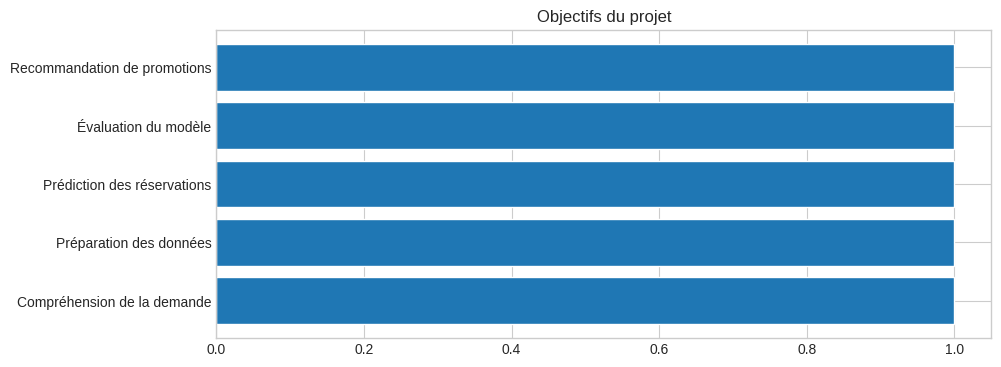

In [ ]:
objectifs = [
    "Compréhension de la demande",
    "Préparation des données",
    "Prédiction des réservations",
    "Évaluation du modèle",
    "Recommandation de promotions"
]

plt.figure(figsize=(10,4))
plt.barh(objectifs, [1]*len(objectifs))
plt.title("Objectifs du projet")
plt.show()

## 1.4 Indicateurs clés (KPI)

- Nombre de réservations
- Taux d’occupation
- Créneaux horaires creux
- Impact météo
- Impact calendrier
- Impact événements

In [ ]:
pd.DataFrame({
    "KPI": [
        "Réservations",
        "Taux d'occupation",
        "Heures creuses",
        "Météo",
        "Calendrier",
        "Événements"
    ],
    "Rôle": [
        "Variable cible",
        "Normalisation métier",
        "Décision promotionnelle",
        "Facteur explicatif",
        "Facteur explicatif",
        "Facteur explicatif"
    ]
})


,KPI,Rôle
0,Réservations,Variable cible
1,Taux d'occupation,Normalisation métier
2,Heures creuses,Décision promotionnelle
3,Météo,Facteur explicatif
4,Calendrier,Facteur explicatif
5,Événements,Facteur explicatif


## 1.5 Critères de succès

Le projet est considéré comme réussi si :
- les prédictions sont suffisamment fiables,
- les tendances sont interprétables,
- les promotions sont cohérentes,
- le modèle généralise à d’autres contextes.

# 2. Data Understanding

Cette phase consiste à explorer la base brute afin de :
- comprendre sa structure,
- évaluer la qualité des données,
- analyser la variable cible,
- détecter les anomalies éventuelles.


In [ ]:
INPUT_PATH_A = "/content/drive/MyDrive/PFE/base_A_finale_2024_2025.csv"
df_A_raw = pd.read_csv(INPUT_PATH_A, sep=",")

print("Shape :", df_A_raw.shape)
display(df_A_raw.head())

Shape : (17379, 20)


,date,jour_semaine,saison,jour_ouvrable,reservations,heure_num,temperature_c,humidite_pct,vent_kmh,meteo,mois,est_weekend,semaine_annee,trimestre,ferie,nom_jour_ferie,is_vacances_scolaires,nom_event_local,heure_sin,heure_cos
0,2024-01-01,lundi,hiver,0,1,0,7.4,77,26.7,nuit_claire,1,0,1,1,1,1er janvier,1,NaN,0.000000,1.000000
1,2024-01-01,lundi,hiver,0,1,1,7.3,76,25.6,nuit_claire,1,0,1,1,1,1er janvier,1,NaN,0.258819,0.965926
2,2024-01-01,lundi,hiver,0,1,2,7.1,75,25.9,nuit_claire,1,0,1,1,1,1er janvier,1,NaN,0.500000,0.866025
3,2024-01-01,lundi,hiver,0,1,3,7.1,71,24.6,nuit_claire,1,0,1,1,1,1er janvier,1,NaN,0.707107,0.707107
4,2024-01-01,lundi,hiver,0,1,4,7.1,71,25.0,nuit_claire,1,0,1,1,1,1er janvier,1,NaN,0.866025,0.500000


## 2.1 Structure et types des données


In [ ]:
print("Colonnes :")
print(df_A_raw.columns.tolist())

df_A_raw.info()

Colonnes :
['date', 'jour_semaine', 'saison', 'jour_ouvrable', 'reservations', 'heure_num', 'temperature_c', 'humidite_pct', 'vent_kmh', 'meteo', 'mois', 'est_weekend', 'semaine_annee', 'trimestre', 'ferie', 'nom_jour_ferie', 'is_vacances_scolaires', 'nom_event_local', 'heure_sin', 'heure_cos']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   17379 non-null  object 
 1   jour_semaine           17379 non-null  object 
 2   saison                 17379 non-null  object 
 3   jour_ouvrable          17379 non-null  int64  
 4   reservations           17379 non-null  int64  
 5   heure_num              17379 non-null  int64  
 6   temperature_c          17379 non-null  float64
 7   humidite_pct           17379 non-null  int64  
 8   vent_kmh               17379 non-null  float64
 9   meteo             

## 2.2 Valeurs manquantes et doublons

In [ ]:
print("Doublons :", df_A_raw.duplicated().sum())


missing_pct = df_A_raw.isna().mean().sort_values(ascending=False) * 100
# Convert the series to a DataFrame and rename its column
missing_pct = missing_pct.to_frame().rename(columns={0: "pct_manquant"})

Doublons : 0


<Figure size 1000x600 with 0 Axes>

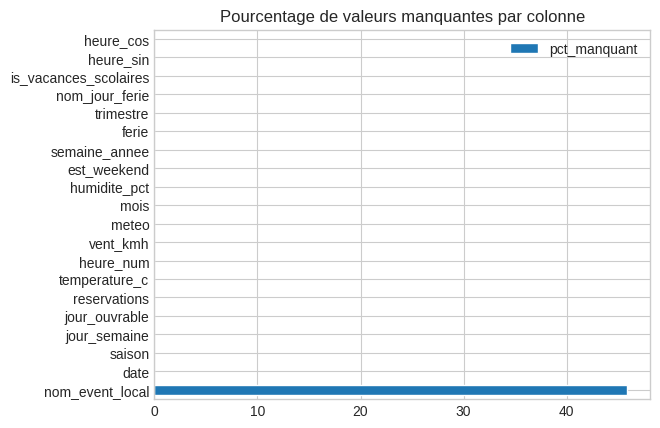

In [ ]:
plt.figure(figsize=(10,6))
missing_pct[missing_pct > 0].sort_values(by="pct_manquant").plot(kind="barh")
plt.title("Pourcentage de valeurs manquantes par colonne")
plt.show()

## 2.3 Analyse de la variable cible

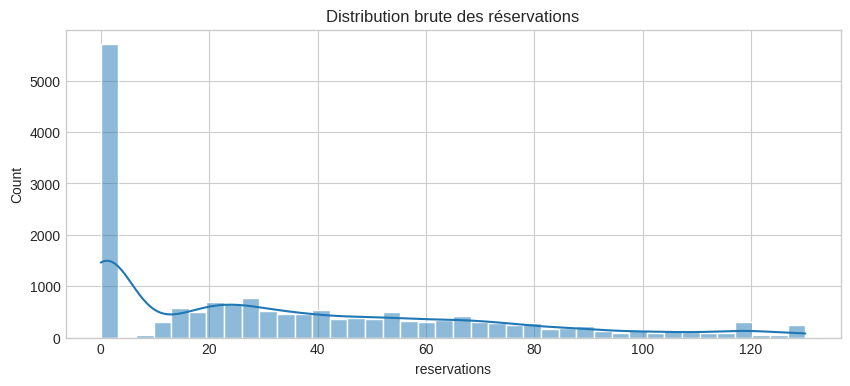

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(df_A_raw["reservations"], bins=40, kde=True)
plt.title("Distribution brute des réservations")
plt.show()

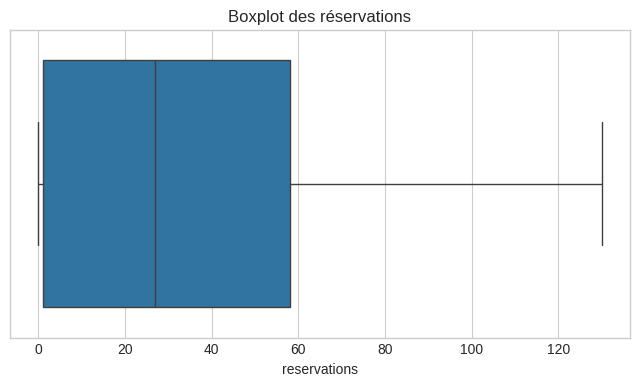

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_A_raw["reservations"])
plt.title("Boxplot des réservations")
plt.show()

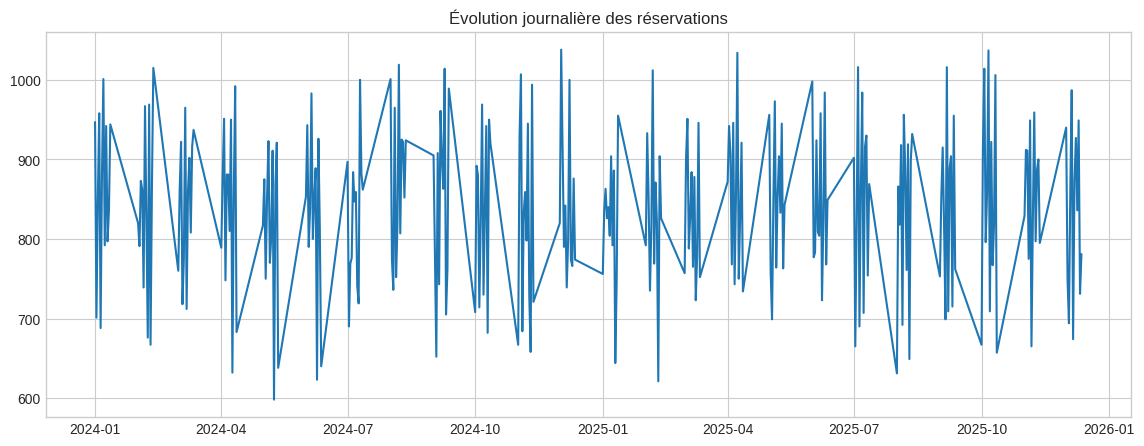

In [ ]:
df_A_raw["date"] = pd.to_datetime(df_A_raw["date"], dayfirst=True, errors="coerce")

df_daily = (
    df_A_raw.dropna(subset=["date"])
    .groupby("date")["reservations"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(14,5))
plt.plot(df_daily.index, df_daily.values)
plt.title("Évolution journalière des réservations")
plt.show()

## 2.5 Analyse horaire

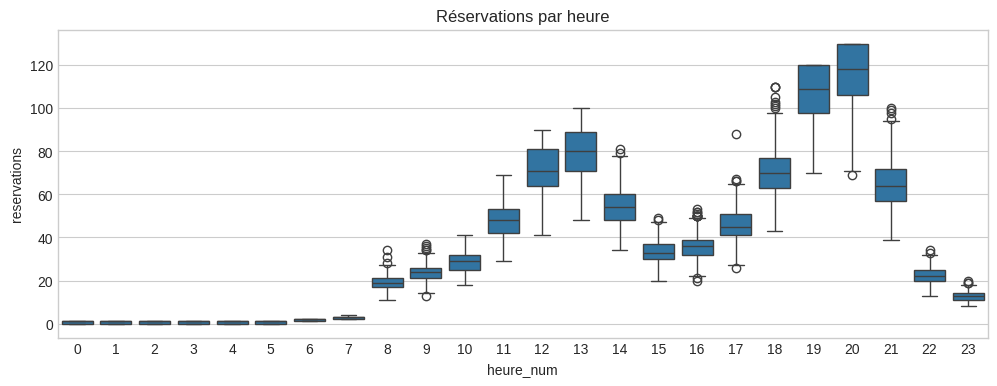

In [ ]:
heure_col = "heure_num" if "heure_num" in df_A_raw.columns else "heure"

plt.figure(figsize=(12,4))
sns.boxplot(data=df_A_raw, x=heure_col, y="reservations")
plt.title("Réservations par heure")
plt.show()

## 2.6 Analyse par jour de semaine

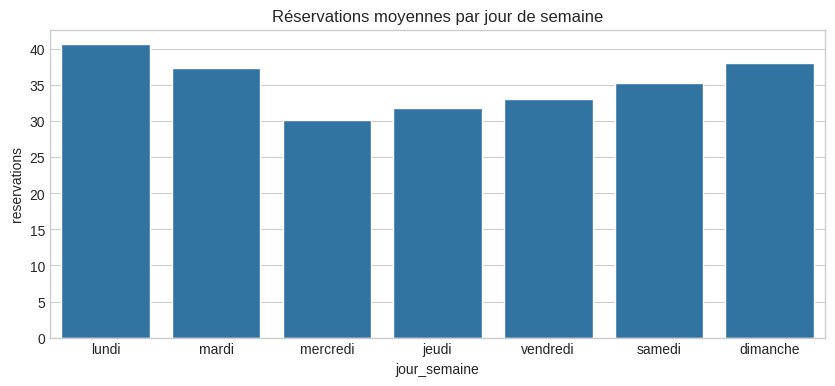

In [ ]:
ordre_jours = ["lundi","mardi","mercredi","jeudi","vendredi","samedi","dimanche"]

if "jour_semaine" in df_A_raw.columns:
    plt.figure(figsize=(10,4))
    sns.barplot(
        data=df_A_raw,
        x="jour_semaine",
        y="reservations",
        order=ordre_jours,
        estimator=np.mean,
        errorbar=None
    )
    plt.title("Réservations moyennes par jour de semaine")
    plt.show()

## 2.7 Analyse par saison

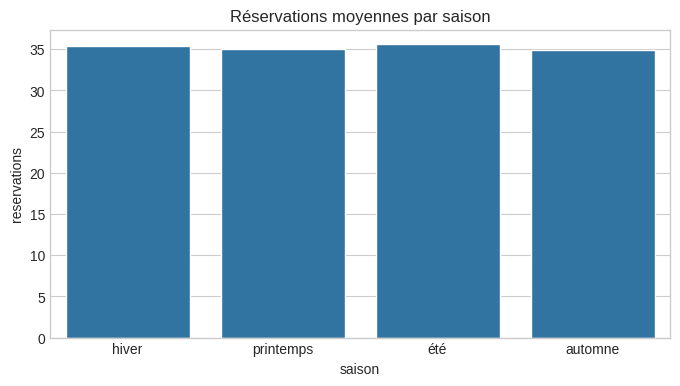

In [ ]:
if "saison" in df_A_raw.columns:
    plt.figure(figsize=(8,4))
    sns.barplot(
        data=df_A_raw,
        x="saison",
        y="reservations",
        estimator=np.mean,
        errorbar=None
    )
    plt.title("Réservations moyennes par saison")
    plt.show()

## 2.8 Analyse par météo

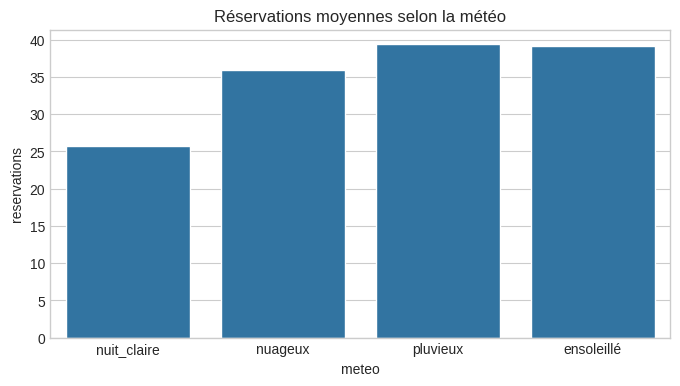

In [ ]:
if "meteo" in df_A_raw.columns:
    plt.figure(figsize=(8,4))
    sns.barplot(
        data=df_A_raw,
        x="meteo",
        y="reservations",
        estimator=np.mean,
        errorbar=None
    )
    plt.title("Réservations moyennes selon la météo")
    plt.show()

## 2.9 Synthèse Data Understanding

In [ ]:
pd.DataFrame([{
    "lignes": df_A_raw.shape[0],
    "colonnes": df_A_raw.shape[1],
    "doublons": int(df_A_raw.duplicated().sum()),
    "colonnes_avec_manquants": int((df_A_raw.isna().sum() > 0).sum()),
    "reservation_min": df_A_raw["reservations"].min(),
    "reservation_max": df_A_raw["reservations"].max(),
    "reservation_moyenne": df_A_raw["reservations"].mean()
}])

,lignes,colonnes,doublons,colonnes_avec_manquants,reservation_min,reservation_max,reservation_moyenne
0,17379,20,0,2,0,130,35.218425


# Conclusion du notebook

Ce notebook a couvert :
- la compréhension du besoin métier (Business Understanding),
- l’exploration des données brutes (Data Understanding).

Les constats réalisés guideront la phase suivante :
**Data Preparation**, qui inclura :
- nettoyage approfondi,
- enrichissement par API,
- création de variables explicatives,
- préparation de la base pour la modélisation.

In [ ]:
print("✅ Notebook Business Understanding & Data Understanding terminé.")
print("➡️ Prochaine étape : Data Preparation.")

✅ Notebook Business Understanding & Data Understanding terminé.
➡️ Prochaine étape : Data Preparation.
